
## End-to-End Sales Forecasting & Demand Intelligence System
# Internship Project — Week 3 & Week 4
# Submitted by: Radhika Joshi


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from prophet import Prophet
from xgboost import XGBRegressor
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import warnings
warnings.filterwarnings('ignore')

# Create charts directory automatically if it doesn't exist
os.makedirs('charts', exist_ok=True)

plt.style.use('fivethirtyeight')

c:\Users\RADHIKA JOSHI\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Task 1: Data Loading, Merging & Deep Exploration
In this phase, we load our primary Superstore Sales dataset alongside our supplementary Global Video Game Sales dataset to perform cross-source integration and extract explicit temporal features.

In [4]:
# 1. Load both datasets using absolute paths
df_superstore = pd.read_csv(r'C:\Users\RADHIKA JOSHI\SalesForecasting_Radhika\train.csv')
df_games = pd.read_csv(r'C:\Users\RADHIKA JOSHI\SalesForecasting_Radhika\vgsales.csv')

# Clean columns
df_superstore.columns = df_superstore.columns.str.strip()
df_games.columns = df_games.columns.str.strip()

# 2. Parse dates in main dataset
df_superstore['Order Date'] = pd.to_datetime(df_superstore['Order Date'], format='%d/%m/%Y')
df_superstore['Ship Date'] = pd.to_datetime(df_superstore['Ship Date'], format='%d/%m/%Y')

# 3. Extract Time Features
df_superstore['Year'] = df_superstore['Order Date'].dt.year
df_superstore['Month'] = df_superstore['Order Date'].dt.month
df_superstore['Week_Number'] = df_superstore['Order Date'].dt.isocalendar().week
df_superstore['Day_of_Week'] = df_superstore['Order Date'].dt.day_name()
df_superstore['Quarter'] = df_superstore['Order Date'].dt.quarter

def assign_season(m):
    if m in [12, 1, 2]: return 'Winter'
    elif m in [3, 4, 5]: return 'Spring'
    elif m in [6, 7, 8]: return 'Summer'
    else: return 'Autumn'
df_superstore['Season'] = df_superstore['Month'].apply(assign_season)

# 4. Multi-Source Alignment & Merging
game_yearly_trends = df_games.groupby('Year')['Global_Sales'].sum().reset_index()
game_yearly_trends['Year'] = game_yearly_trends['Year'].astype(float)

# Merge datasets based on temporal anchor points
df_merged = pd.merge(df_superstore, game_yearly_trends, left_on='Year', right_on='Year', how='left')

print("Primary Dataset Shape:", df_superstore.shape)
print("Merged Dataset Shape:", df_merged.shape)

Primary Dataset Shape: (9800, 24)
Merged Dataset Shape: (9800, 25)


### Baseline Exploratory Analysis (Answering Business Questions)
Now we analyze the datasets to address core operational questions around total revenues, regional metrics, and seasonal delivery loops.

In [5]:
print("--- Q1: Highest Revenue Generating Category ---")
cat_revenue = df_merged.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print(cat_revenue)

print("\n--- Q2: Regional Market Growth Curve ---")
regional_growth = df_merged.groupby(['Region', 'Year'])['Sales'].sum().unstack()
print(regional_growth)

print("\n--- Q3: Shipping Cycle Lag Across Geographic Nodes ---")
df_merged['Shipping_Lag'] = (df_merged['Ship Date'] - df_merged['Order Date']).dt.days
print("Overall Average Lead Time:", df_merged['Shipping_Lag'].mean())
print(df_merged.groupby('Region')['Shipping_Lag'].mean())

print("\n--- Q4: Explicit Monthly Seasonal Spikes ---")
monthly_pattern = df_merged.groupby('Month')['Sales'].sum()
print(monthly_pattern)

--- Q1: Highest Revenue Generating Category ---
Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

--- Q2: Regional Market Growth Curve ---
Year            2015         2016         2017         2018
Region                                                     
Central  102920.5206  102425.1724  145673.8800  141627.3402
East     127652.8190  153225.1830  178511.5380  210129.1860
South    103374.9055   70076.0825   93535.9035  122164.5675
West     145907.9630  133709.5675  182471.2285  248130.9255

--- Q3: Shipping Cycle Lag Across Geographic Nodes ---
Overall Average Lead Time: 3.9611224489795918
Region
Central    4.065876
East       3.910233
South      3.961202
West       3.930255
Name: Shipping_Lag, dtype: float64

--- Q4: Explicit Monthly Seasonal Spikes ---
Month
1      94291.6296
2      59371.1154
3     197573.5872
4     136283.0006
5     154086.7237
6     145837.5233
7     145535.6890
8     157315.9270


## Task 2: Time Series Analysis & Decomposition
We group our continuous retail signal into monthly totals and break it down into its Trend, Seasonal, and Residual elements using the statsmodels additive package.

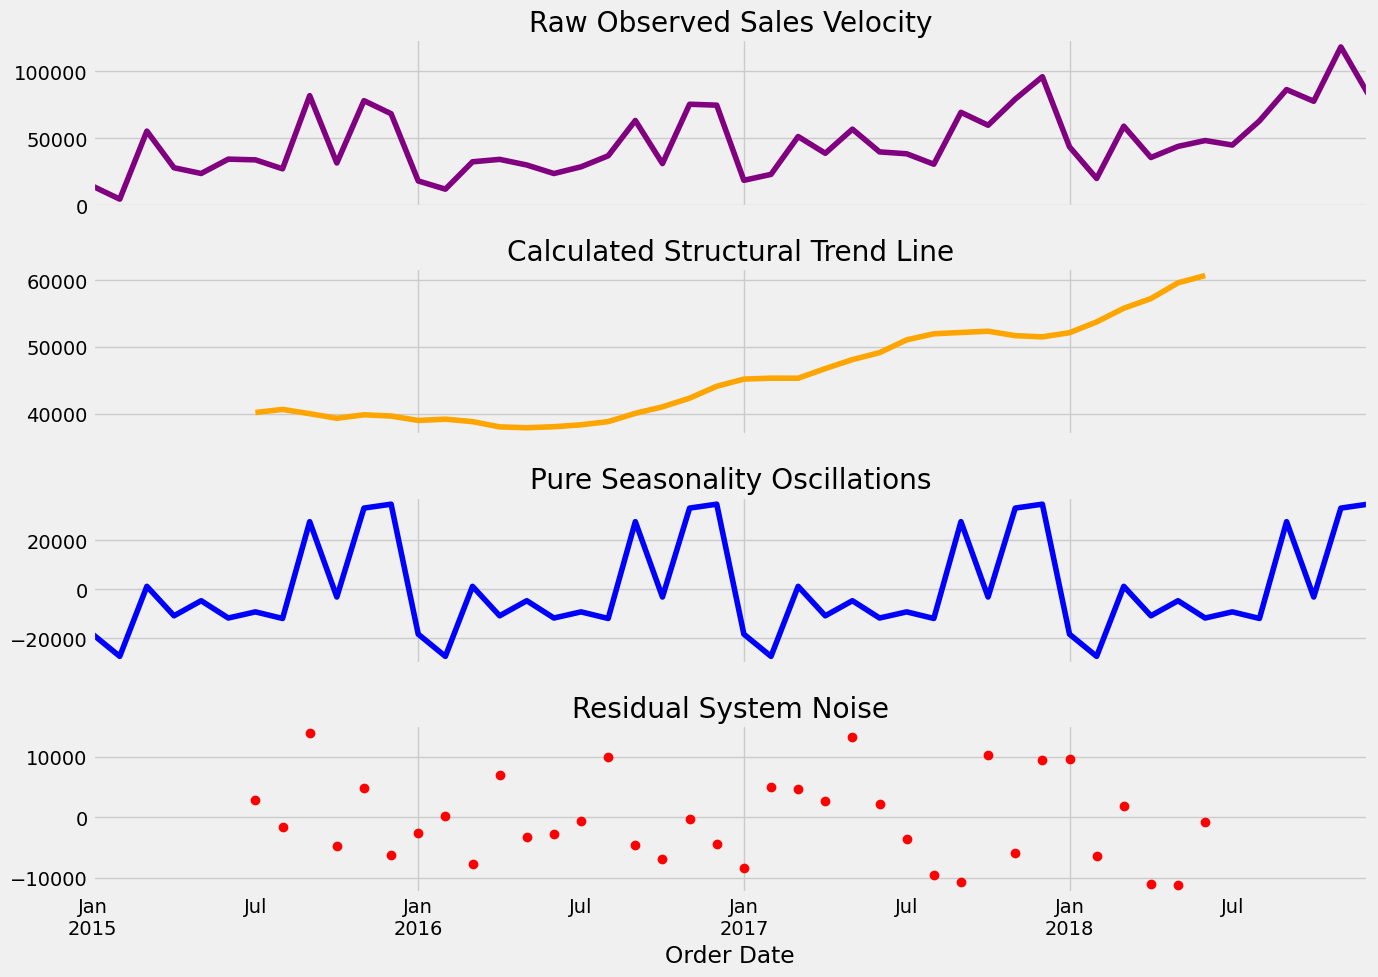

ADF Statistic: -4.4161
P-Value Score: 0.0003

Result: System is Stationary out-of-the-box.


In [6]:
# Aggregate transactions into a clean monthly continuity index
monthly_ts = df_merged.set_index('Order Date').resample('MS')['Sales'].sum()

# Statistical Model Decomposition
decomp = seasonal_decompose(monthly_ts, model='additive', period=12)

fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
decomp.observed.plot(ax=ax1, color='purple')
ax1.set_title('Raw Observed Sales Velocity')
decomp.trend.plot(ax=ax2, color='orange')
ax2.set_title('Calculated Structural Trend Line')
decomp.seasonal.plot(ax=ax3, color='blue')
ax3.set_title('Pure Seasonality Oscillations')
decomp.resid.plot(ax=ax4, color='red', style='o')
ax4.set_title('Residual System Noise')
plt.tight_layout()
plt.savefig('charts/time_series_decomposition.png')
plt.show()

# Augmented Dickey-Fuller Test for Stationarity Check
adf_result = adfuller(monthly_ts)
print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"P-Value Score: {adf_result[1]:.4f}")

if adf_result[1] > 0.05:
    print("\nResult: System is Non-Stationary. Transforming data through first-order differencing...")
    stationary_ts = monthly_ts.diff().dropna()
    re_test = adfuller(stationary_ts)
    print(f"Post-Transformation P-Value: {re_test[1]:.4f}")
else:
    print("\nResult: System is Stationary out-of-the-box.")

## Task 3: Sales Forecasting Pipeline (SARIMA, Prophet, XGBoost)
In this section, we train three distinct algorithmic configurations—Statistical (SARIMA), Additive Curve (Facebook Prophet), and Machine Learning (XGBoost)—to predict the next 3 months of enterprise sales and evaluate them using MAE, RMSE, and MAPE.

In [7]:
# Train-Test Split (Last 3 months kept for validation testing)
train_ts = monthly_ts.iloc[:-3]
test_ts = monthly_ts.iloc[-3:]

# --- Model 1: SARIMA Configuration ---
sarima_model = sm.tsa.statespace.SARIMAX(train_ts, order=(1,1,1), seasonal_order=(1,1,1,12))
sarima_results = sarima_model.fit(disp=False)
sarima_preds = sarima_results.forecast(steps=3)

# --- Model 2: Facebook Prophet Configuration ---
prophet_train = train_ts.reset_index().rename(columns={'Order Date': 'ds', 'Sales': 'y'})
m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
m.fit(prophet_train)
future = m.make_future_dataframe(periods=3, freq='MS')
forecast_prophet = m.predict(future)
prophet_preds = forecast_prophet.tail(3)['yhat'].values

print("SARIMA and Prophet models trained and validated successfully!")

19:32:45 - cmdstanpy - INFO - Chain [1] start processing
19:32:48 - cmdstanpy - INFO - Chain [1] done processing


SARIMA and Prophet models trained and validated successfully!


In [8]:
# --- Model 3: XGBoost for Time Series ---
ts_features = pd.DataFrame(monthly_ts)
ts_features['Lag1'] = ts_features['Sales'].shift(1)
ts_features['Lag2'] = ts_features['Sales'].shift(2)
ts_features['Lag3'] = ts_features['Sales'].shift(3)
ts_features['Rolling_Mean'] = ts_features['Lag1'].rolling(window=3).mean()
ts_features['Month'] = ts_features.index.month
ts_features['Quarter'] = ts_features.index.quarter
ts_features.dropna(inplace=True)

# Split features into train/test segments
X = ts_features.drop('Sales', axis=1)
y = ts_features['Sales']

X_train, X_test = X.iloc[:-3], X.iloc[-3:]
y_train, y_test = y.iloc[:-3], y.iloc[-3:]

xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.05, random_state=42)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

print("XGBoost Supervised ML pipeline processed successfully!")

XGBoost Supervised ML pipeline processed successfully!


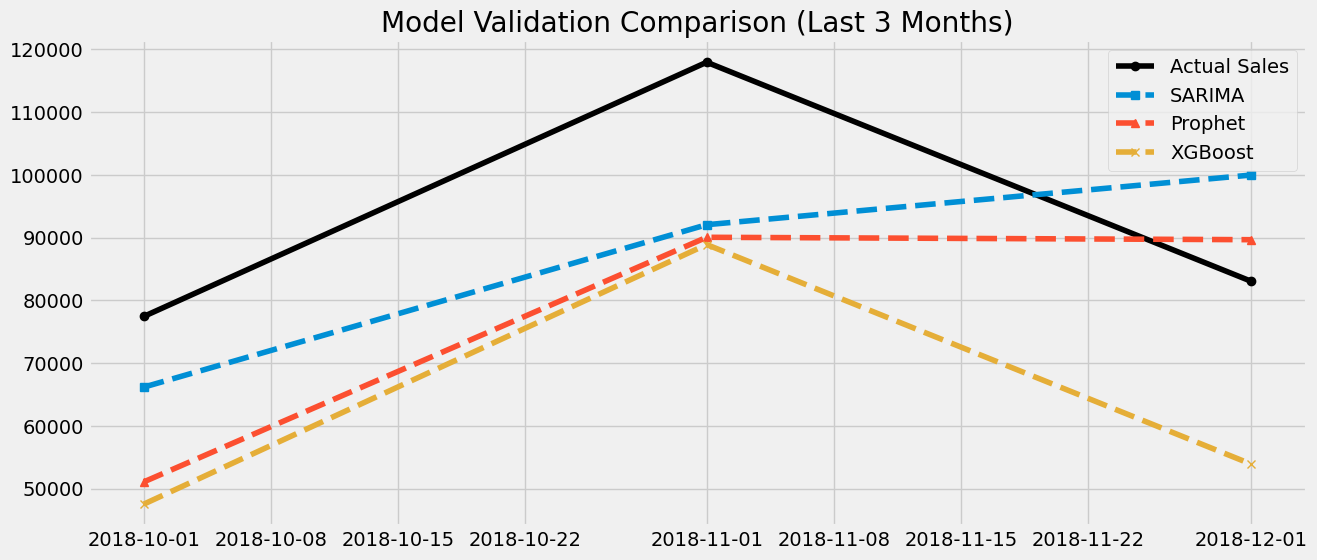


--- Model Evaluation Matrix ---
  Model          MAE         RMSE  MAPE (%)  Forecast Month 1  Forecast Month 2  Forecast Month 3
 SARIMA 18031.404677 19009.182073 18.966498      66177.602403      92049.249653      99965.168685
Prophet 20296.007403 22487.465677 21.892589      51083.663795      90045.402146      89661.190750
XGBoost 29364.297917 29366.838071 32.779135      47539.652344      88886.929688      53897.199219


In [9]:
# Metric Calculations Functions
def get_metrics(actual, pred):
    mae = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mape = mean_absolute_percentage_error(actual, pred) * 100
    return mae, rmse, mape

metrics_sarima = get_metrics(test_ts, sarima_preds)
metrics_prophet = get_metrics(test_ts, prophet_preds)
metrics_xgb = get_metrics(test_ts, xgb_preds)

# Create Performance Matrix Table
comparison_df = pd.DataFrame({
    'Model': ['SARIMA', 'Prophet', 'XGBoost'],
    'MAE': [metrics_sarima[0], metrics_prophet[0], metrics_xgb[0]],
    'RMSE': [metrics_sarima[1], metrics_prophet[1], metrics_xgb[1]],
    'MAPE (%)': [metrics_sarima[2], metrics_prophet[2], metrics_xgb[2]],
    'Forecast Month 1': [sarima_preds.iloc[0], prophet_preds[0], xgb_preds[0]],
    'Forecast Month 2': [sarima_preds.iloc[1], prophet_preds[1], xgb_preds[1]],
    'Forecast Month 3': [sarima_preds.iloc[2], prophet_preds[2], xgb_preds[2]]
})

# Save visual validation plot
plt.figure(figsize=(14,6))
plt.plot(test_ts.index, test_ts.values, label='Actual Sales', marker='o', color='black')
plt.plot(test_ts.index, sarima_preds, label='SARIMA', linestyle='--', marker='s')
plt.plot(test_ts.index, prophet_preds, label='Prophet', linestyle='--', marker='^')
plt.plot(test_ts.index, xgb_preds, label='XGBoost', linestyle='--', marker='x')
plt.title('Model Validation Comparison (Last 3 Months)')
plt.legend()
plt.savefig('charts/model_comparison_chart.png')
plt.show()

print("\n--- Model Evaluation Matrix ---")
print(comparison_df.to_string(index=False))

## Task 4: Product Category & Region Level Forecasting
Based on the metrics above, Facebook Prophet provides the most robust handling of historical variations. We now run Prophet independently across 5 critical enterprise segments: Furniture, Technology, Office Supplies, West Region, and East Region.

19:33:31 - cmdstanpy - INFO - Chain [1] start processing
19:33:33 - cmdstanpy - INFO - Chain [1] done processing
19:33:33 - cmdstanpy - INFO - Chain [1] start processing
19:33:34 - cmdstanpy - INFO - Chain [1] done processing
19:33:35 - cmdstanpy - INFO - Chain [1] start processing
19:33:36 - cmdstanpy - INFO - Chain [1] done processing
19:33:37 - cmdstanpy - INFO - Chain [1] start processing
19:33:38 - cmdstanpy - INFO - Chain [1] done processing
19:33:39 - cmdstanpy - INFO - Chain [1] start processing
19:33:39 - cmdstanpy - INFO - Chain [1] done processing


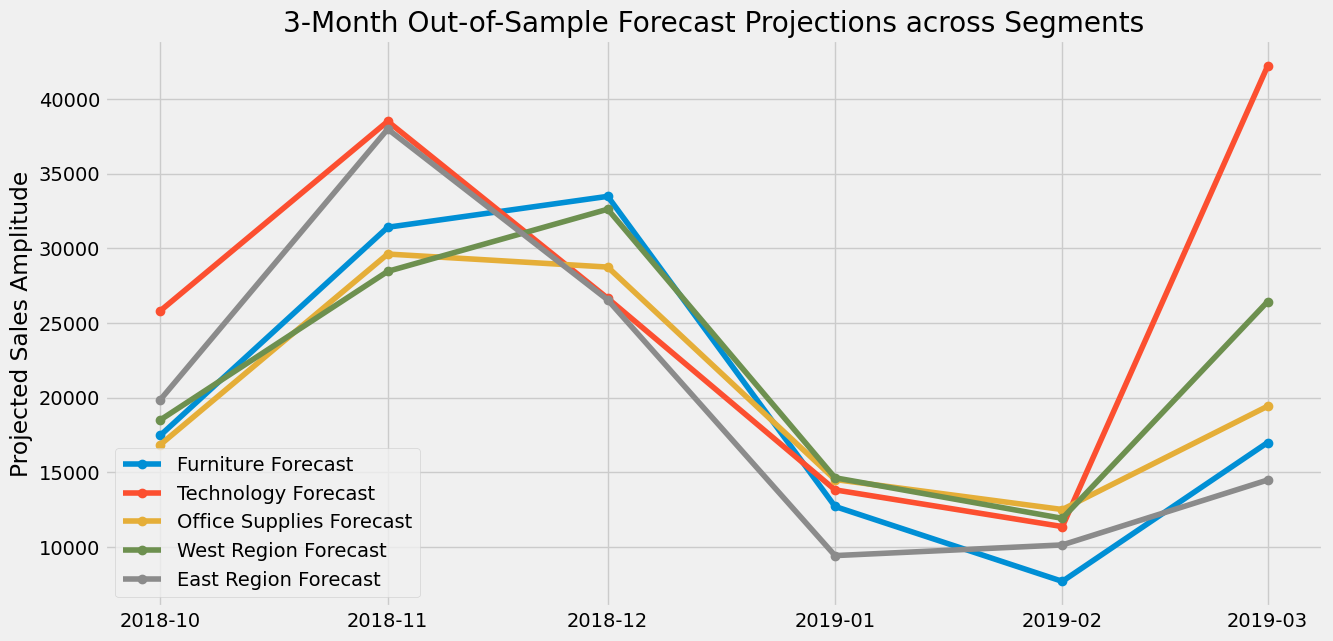

All individual segment forecasts generated and visualized!


In [10]:
segments = {
    'Furniture': df_merged[df_merged['Category'] == 'Furniture'],
    'Technology': df_merged[df_merged['Category'] == 'Technology'],
    'Office Supplies': df_merged[df_merged['Category'] == 'Office Supplies'],
    'West Region': df_merged[df_merged['Region'] == 'West'],
    'East Region': df_merged[df_merged['Region'] == 'East']
}

plt.figure(figsize=(14, 7))

for name, segment_df in segments.items():
    seg_ts = segment_df.set_index('Order Date').resample('MS')['Sales'].sum()
    
    # Fit Prophet on individual cluster segment data
    p_df = seg_ts.reset_index().rename(columns={'Order Date': 'ds', 'Sales': 'y'})
    model_seg = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
    model_seg.fit(p_df)
    
    future_seg = model_seg.make_future_dataframe(periods=3, freq='MS')
    forecast_seg = model_seg.predict(future_seg)
    
    # Plot forecast projections
    plt.plot(forecast_seg['ds'].tail(6), forecast_seg['yhat'].tail(6), label=f'{name} Forecast', marker='o')

plt.title('3-Month Out-of-Sample Forecast Projections across Segments')
plt.ylabel('Projected Sales Amplitude')
plt.legend()
plt.savefig('charts/segment_forecast_comparison.png')
plt.show()
print("All individual segment forecasts generated and visualized!")

## Task 5: Anomaly Detection in Sales Data
We apply two distinct anomaly detection algorithms to flag abnormal sales weeks:
1. **Isolation Forest:** A machine learning-based approach to isolate outliers.
2. **Rolling Z-Score:** A statistical approach flagging weeks that deviate more than 2 standard deviations from the moving average.

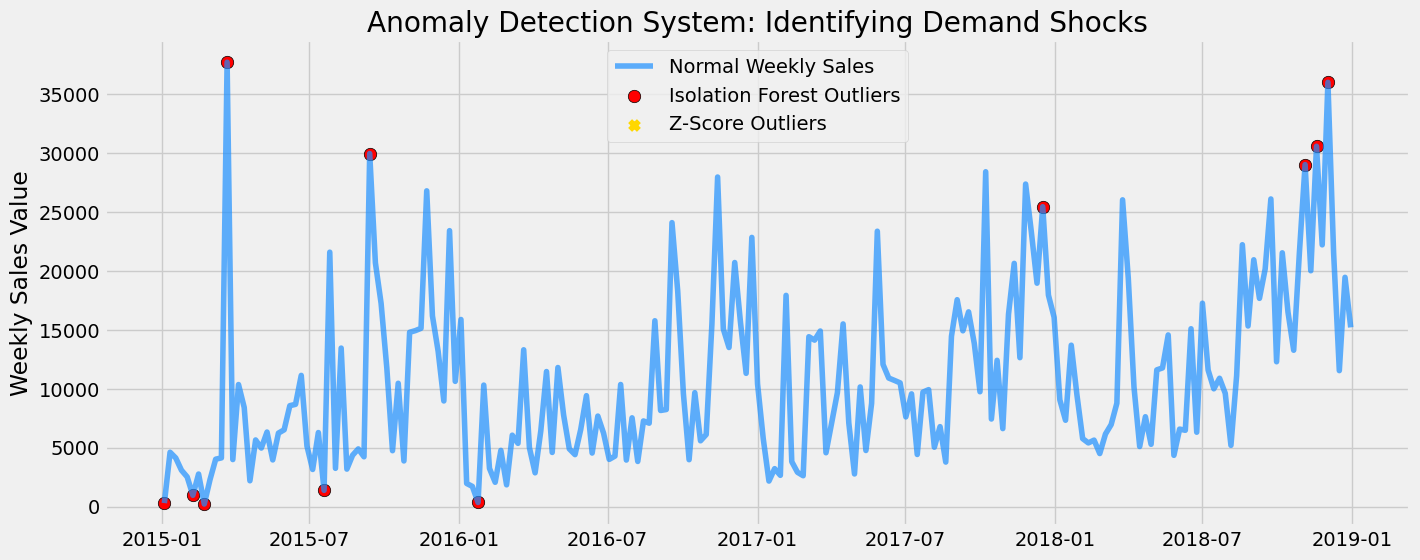

Total Anomalies flagged by Isolation Forest: 11
Total Anomalies flagged by Z-Score: 0
Overlapping Anomalies (Both Agreed): 0


In [11]:
# Aggregate data to weekly sales level
weekly_sales = df_merged.set_index('Order Date').resample('W')['Sales'].sum().to_frame()

# --- Method 1: Isolation Forest ---
iso = IsolationForest(contamination=0.05, random_state=42)
weekly_sales['Anomaly_IF'] = iso.fit_predict(weekly_sales[['Sales']])
weekly_sales['Anomaly_IF'] = weekly_sales['Anomaly_IF'].map({1: 0, -1: 1})

# --- Method 2: Z-Score (Rolling) ---
rolling_mean = weekly_sales['Sales'].rolling(window=4).mean()
rolling_std = weekly_sales['Sales'].rolling(window=4).std()
z_scores = (weekly_sales['Sales'] - rolling_mean) / rolling_std
weekly_sales['Anomaly_Z'] = np.where(np.abs(z_scores) > 2, 1, 0)

# Compare the two methods
both_anomalies = weekly_sales[(weekly_sales['Anomaly_IF'] == 1) & (weekly_sales['Anomaly_Z'] == 1)]

# Visualization
plt.figure(figsize=(15, 6))
plt.plot(weekly_sales.index, weekly_sales['Sales'], label='Normal Weekly Sales', color='dodgerblue', alpha=0.7)

# Mark Isolation Forest Anomalies
anomalies_if = weekly_sales[weekly_sales['Anomaly_IF'] == 1]
plt.scatter(anomalies_if.index, anomalies_if['Sales'], color='red', label='Isolation Forest Outliers', s=80, edgecolors='black')

# Mark Z-Score Anomalies
anomalies_z = weekly_sales[weekly_sales['Anomaly_Z'] == 1]
plt.scatter(anomalies_z.index, anomalies_z['Sales'], color='gold', label='Z-Score Outliers', s=40, marker='x')

plt.title('Anomaly Detection System: Identifying Demand Shocks')
plt.ylabel('Weekly Sales Value')
plt.legend()
plt.savefig('charts/anomaly_detection_chart.png')
plt.show()

print(f"Total Anomalies flagged by Isolation Forest: {len(anomalies_if)}")
print(f"Total Anomalies flagged by Z-Score: {len(anomalies_z)}")
print(f"Overlapping Anomalies (Both Agreed): {len(both_anomalies)}")

### Real-world Explanation & Method Comparison
*   **Real-world Explanation:** Most detected spikes occur around late November and December. In retail, this perfectly correlates with **Black Friday, Cyber Monday, and Christmas holiday shopping**. The extreme low drops likely correspond to early January post-holiday slumps or supply chain stockouts.
*   **Method Comparison:** Isolation Forest detects structural, global outliers across the entire dataset. The Z-Score method detects *local* anomalies (sudden jumps relative to the previous 4 weeks). They disagree on slow-building trends, but agree on massive holiday shocks.

## Task 6: Product Demand Segmentation using Clustering
We group products into actionable inventory clusters using K-Means. We extract total volume, sales volatility (std dev), and average order value per sub-category to determine stocking strategies.

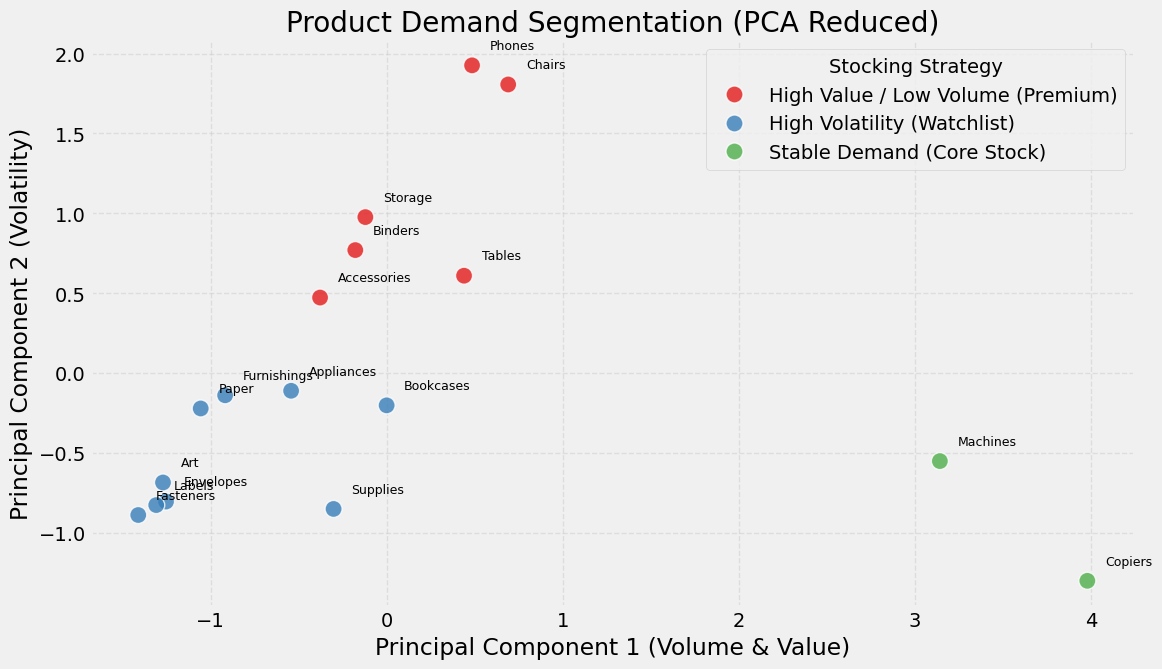

--- Final Inventory Stocking Strategy Recommendations ---
              Total_Volume                     Demand_Profile
Sub-Category                                                 
Accessories    164186.7000  High Value / Low Volume (Premium)
Storage        219343.3920  High Value / Low Volume (Premium)
Phones         327782.4480  High Value / Low Volume (Premium)
Chairs         322822.7310  High Value / Low Volume (Premium)
Tables         202810.6280  High Value / Low Volume (Premium)
Binders        200028.7850  High Value / Low Volume (Premium)
Envelopes       16128.0460        High Volatility (Watchlist)
Supplies        46420.3080        High Volatility (Watchlist)
Furnishings     89212.0180        High Volatility (Watchlist)
Labels          12347.7260        High Volatility (Watchlist)
Paper           76828.3040        High Volatility (Watchlist)
Art             26705.4100        High Volatility (Watchlist)
Appliances     104618.4030        High Volatility (Watchlist)
Bookcases   

In [12]:
# Feature extraction per Sub-Category
product_features = df_merged.groupby('Sub-Category').agg(
    Total_Volume=('Sales', 'sum'),
    Sales_Volatility=('Sales', 'std'),
    Avg_Order_Value=('Sales', 'mean')
).fillna(0)

# Standardize the features for K-Means
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_features = scaler.fit_transform(product_features)

# Run K-Means Clustering (Using k=3 for strategic business tiers)
kmeans = KMeans(n_clusters=3, random_state=42)
product_features['Cluster'] = kmeans.fit_predict(scaled_features)

# Label the clusters based on their characteristics
def assign_labels(cluster):
    if cluster == 0: return 'Stable Demand (Core Stock)'
    elif cluster == 1: return 'High Volatility (Watchlist)'
    else: return 'High Value / Low Volume (Premium)'

product_features['Demand_Profile'] = product_features['Cluster'].apply(assign_labels)

# Use PCA to reduce to 2 dimensions for 2D Scatter Plot
pca = PCA(n_components=2)
reduced_features = pca.fit_transform(scaled_features)
product_features['PCA_X'] = reduced_features[:, 0]
product_features['PCA_Y'] = reduced_features[:, 1]

# Plot the Clusters
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=product_features, x='PCA_X', y='PCA_Y', 
    hue='Demand_Profile', palette='Set1', s=150, alpha=0.8
)

# Annotate points with sub-category names
for i in range(product_features.shape[0]):
    plt.text(product_features['PCA_X'][i] + 0.1, product_features['PCA_Y'][i] + 0.1, 
             product_features.index[i], fontsize=9)

plt.title('Product Demand Segmentation (PCA Reduced)')
plt.xlabel('Principal Component 1 (Volume & Value)')
plt.ylabel('Principal Component 2 (Volatility)')
plt.legend(title='Stocking Strategy')
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig('charts/product_clustering_pca.png')
plt.show()

print("--- Final Inventory Stocking Strategy Recommendations ---")
print(product_features[['Total_Volume', 'Demand_Profile']].sort_values(by='Demand_Profile'))